In [1]:
!pip install swig
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 48.8 MB/s eta 0:00:00


# Distributional Reinforcement Learning: DQN vs C51 on LunarLander-v2
**COMP-579 — Group 10**

This notebook implements and compares:
- **DQN** (Mnih et al., 2015) — standard deep Q-network baseline
- **C51 / Categorical DQN** (Bellemare, Dabney & Munos, 2017) — distributional RL

We also run an ablation study varying the number of atoms N ∈ {5, 11, 21, 51}.

**Run order:**
1. Run **Section 1–3** cells (imports + all class/function definitions).
2. Run **Section 4** experiment cells one at a time — each saves its results to `results/` immediately so progress is not lost.
3. Run **Section 5** plotting cells once experiments are done.

---
## Section 1 — Imports & Setup

In [2]:
import os
import time
import random

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('PyTorch version :', torch.__version__)
print('Device          :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version : 2.10.0+cu128
Device          : cuda


---
## Section 2 — Algorithm Implementations
### 2.1 Neural Networks

In [3]:
class DQNNetwork(nn.Module):
    """
    MLP for DQN. Outputs one Q-value per action.
    Output shape: [batch, n_actions]
    """
    def __init__(self, state_dim, n_actions, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class C51Network(nn.Module):
    """
    MLP for C51. Outputs a probability distribution over N atoms for each action.
    Output shape: [batch, n_actions, n_atoms]  (softmax applied over atoms)
    """
    def __init__(self, state_dim, n_actions, n_atoms, hidden_dim=128):
        super().__init__()
        self.n_actions = n_actions
        self.n_atoms   = n_atoms
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions * n_atoms),
        )

    def forward(self, x):
        logits = self.net(x).view(-1, self.n_actions, self.n_atoms)
        return F.softmax(logits, dim=-1)  # [batch, n_actions, n_atoms]

    def get_q_values(self, x, atoms):
        """E[Z(s,a)] = sum_i z_i * p_i(s,a).  Returns [batch, n_actions]."""
        probs = self.forward(x)                             # [B, A, N]
        return (probs * atoms[None, None, :]).sum(-1)       # [B, A]

### 2.2 Replay Buffer

In [4]:
class ReplayBuffer:
    """Fixed-size circular replay buffer. All arrays are pre-allocated."""

    def __init__(self, capacity, state_dim):
        self.capacity = capacity
        self.ptr  = 0
        self.size = 0
        self.states      = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions     = np.zeros(capacity,              dtype=np.int64)
        self.rewards     = np.zeros(capacity,              dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones       = np.zeros(capacity,              dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        self.states[self.ptr]      = state
        self.actions[self.ptr]     = action
        self.rewards[self.ptr]     = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr]       = float(done)
        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (self.states[idx], self.actions[idx], self.rewards[idx],
                self.next_states[idx], self.dones[idx])

    def __len__(self):
        return self.size

### 2.3 DQN Agent

In [5]:
class DQNAgent:
    """
    Standard DQN (Mnih et al., 2015).
    - Linear epsilon-greedy exploration
    - MSE TD loss
    - Hard target network sync every `target_update_freq` gradient steps
    - Gradient clipping to L2 norm 10
    """

    def __init__(self, state_dim, n_actions, lr=6.25e-5, gamma=0.99,
                 eps_start=1.0, eps_end=0.01, eps_decay_steps=100_000,
                 target_update_freq=1_000, hidden_dim=128, device='cpu'):
        self.n_actions         = n_actions
        self.gamma             = gamma
        self.eps_start         = eps_start
        self.eps_end           = eps_end
        self.eps_decay_steps   = eps_decay_steps
        self.target_update_freq = target_update_freq
        self.device            = device
        self._update_count     = 0

        self.online_net = DQNNetwork(state_dim, n_actions, hidden_dim).to(device)
        self.target_net = DQNNetwork(state_dim, n_actions, hidden_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)

    def get_epsilon(self, env_step):
        frac = min(env_step / self.eps_decay_steps, 1.0)
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    def select_action(self, state, env_step):
        if np.random.random() < self.get_epsilon(env_step):
            return np.random.randint(self.n_actions)
        s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.online_net(s).argmax(1).item()

    def update(self, states, actions, rewards, next_states, dones):
        s  = torch.FloatTensor(states).to(self.device)
        a  = torch.LongTensor(actions).to(self.device)
        r  = torch.FloatTensor(rewards).to(self.device)
        ns = torch.FloatTensor(next_states).to(self.device)
        d  = torch.FloatTensor(dones).to(self.device)

        q = self.online_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q  = self.target_net(ns).max(1)[0]
            targets = r + self.gamma * next_q * (1.0 - d)

        loss = nn.MSELoss()(q, targets)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 10.0)
        self.optimizer.step()

        self._update_count += 1
        if self._update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        return loss.item()

### 2.4 C51 Agent

In [6]:
class C51Agent:
    """
    Categorical DQN / C51 (Bellemare, Dabney & Munos, 2017).

    Models the full return distribution Z(s,a) as a discrete distribution
    over N atoms {z_0,...,z_{N-1}} equally spaced in [V_MIN, V_MAX].

    Training follows Algorithm 1 from the paper:
      1. Compute Bellman targets T_hat_z_j = r + gamma * z_j for each atom j
      2. Project T_hat_z_j onto the atom grid (linear interpolation)
      3. Minimise cross-entropy between projected target and predicted distribution
    """

    def __init__(self, state_dim, n_actions, n_atoms=51, v_min=-300.0, v_max=300.0,
                 lr=6.25e-5, gamma=0.99, eps_start=1.0, eps_end=0.01,
                 eps_decay_steps=100_000, target_update_freq=1_000,
                 hidden_dim=128, device='cpu'):
        self.n_actions          = n_actions
        self.n_atoms            = n_atoms
        self.v_min              = v_min
        self.v_max              = v_max
        self.gamma              = gamma
        self.eps_start          = eps_start
        self.eps_end            = eps_end
        self.eps_decay_steps    = eps_decay_steps
        self.target_update_freq = target_update_freq
        self.device             = device
        self._update_count      = 0

        # Fixed atom support: z_i = V_MIN + i * delta_z
        self.atoms   = torch.linspace(v_min, v_max, n_atoms).to(device)
        self.delta_z = (v_max - v_min) / (n_atoms - 1)

        self.online_net = C51Network(state_dim, n_actions, n_atoms, hidden_dim).to(device)
        self.target_net = C51Network(state_dim, n_actions, n_atoms, hidden_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)

    def get_epsilon(self, env_step):
        frac = min(env_step / self.eps_decay_steps, 1.0)
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    def select_action(self, state, env_step):
        if np.random.random() < self.get_epsilon(env_step):
            return np.random.randint(self.n_actions)
        s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.online_net.get_q_values(s, self.atoms).argmax(1).item()

    def update(self, states, actions, rewards, next_states, dones):
        s  = torch.FloatTensor(states).to(self.device)
        a  = torch.LongTensor(actions).to(self.device)
        r  = torch.FloatTensor(rewards).to(self.device)
        ns = torch.FloatTensor(next_states).to(self.device)
        d  = torch.FloatTensor(dones).to(self.device)
        B  = s.shape[0]

        with torch.no_grad():
            # Greedy action in next state (using target net)
            next_probs   = self.target_net(ns)                                  # [B, A, N]
            next_q       = (next_probs * self.atoms[None, None, :]).sum(-1)     # [B, A]
            next_a       = next_q.argmax(1)                                     # [B]
            next_dist    = next_probs[range(B), next_a]                         # [B, N]

            # Projected Bellman update (Algorithm 1)
            # T_hat_z_j = clip(r + gamma * z_j, V_MIN, V_MAX)
            t_z = r[:, None] + self.gamma * self.atoms[None, :] * (1.0 - d[:, None])
            t_z = t_z.clamp(self.v_min, self.v_max)                            # [B, N]

            # b_j = (T_hat_z_j - V_MIN) / delta_z  in [0, N-1]
            b = (t_z - self.v_min) / self.delta_z                              # [B, N]
            l = b.floor().long().clamp(0, self.n_atoms - 1)
            u = b.ceil().long().clamp(0, self.n_atoms - 1)

            # Linear interpolation weights
            # Edge case: when l == u (b is an integer), assign full probability to l
            same     = (l == u)
            l_weight = torch.where(same, torch.ones_like(b),  u.float() - b)
            u_weight = torch.where(same, torch.zeros_like(b), b - l.float())

            # Accumulate into projected distribution m  [B, N]
            m      = torch.zeros(B, self.n_atoms, device=self.device)
            offset = (torch.arange(B, device=self.device) * self.n_atoms)[:, None]
            m.view(-1).scatter_add_(0, (l + offset).view(-1), (next_dist * l_weight).view(-1))
            m.view(-1).scatter_add_(0, (u + offset).view(-1), (next_dist * u_weight).view(-1))

        # Cross-entropy loss: -sum_i m_i * log p_i(s, a)
        probs     = self.online_net(s)                                          # [B, A, N]
        log_probs = torch.log(probs[range(B), a] + 1e-8)                       # [B, N]
        loss      = -(m * log_probs).sum(1).mean()

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 10.0)
        self.optimizer.step()

        self._update_count += 1
        if self._update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        return loss.item()

---
## Section 3 — Training & Plotting Utilities

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def evaluate(agent, env_name, n_episodes, device):
    """Run n_episodes with greedy policy (no exploration). Returns mean return."""
    env = gym.make(env_name)
    returns = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        done, ep_ret = False, 0.0
        while not done:
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                if isinstance(agent, DQNAgent):
                    action = agent.online_net(s).argmax(1).item()
                else:
                    action = agent.online_net.get_q_values(s, agent.atoms).argmax(1).item()
            state, reward, terminated, truncated, _ = env.step(action)
            done    = terminated or truncated
            ep_ret += reward
        returns.append(ep_ret)
    env.close()
    return float(np.mean(returns))


def run_experiment(
    agent_type,
    seed,
    n_atoms        = 51,
    total_steps    = 500_000,
    warmup_steps   = 10_000,
    batch_size     = 32,
    buffer_size    = 100_000,
    lr             = 6.25e-5,
    gamma          = 0.99,
    eps_start      = 1.0,
    eps_end        = 0.01,
    eps_decay_steps= 100_000,
    target_update_freq = 1_000,
    hidden_dim     = 128,
    v_min          = -300.0,
    v_max          =  300.0,
    eval_every     = 10_000,
    eval_episodes  = 10,
    results_dir    = RESULTS_DIR,
):
    """
    Run one training experiment and save results to results_dir immediately.
    Returns (eval_steps, eval_returns, label).
    """
    set_seed(seed)
    device    = 'cuda' if torch.cuda.is_available() else 'cpu'
    env_name  = 'LunarLander-v3'
    env       = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    shared = dict(
        state_dim=state_dim, n_actions=n_actions, lr=lr, gamma=gamma,
        eps_start=eps_start, eps_end=eps_end, eps_decay_steps=eps_decay_steps,
        target_update_freq=target_update_freq, hidden_dim=hidden_dim, device=device,
    )

    if agent_type == 'dqn':
        agent = DQNAgent(**shared)
        label = f'dqn_seed{seed}'
    else:
        agent = C51Agent(n_atoms=n_atoms, v_min=v_min, v_max=v_max, **shared)
        label = f'c51_atoms{n_atoms}_seed{seed}'

    buffer = ReplayBuffer(buffer_size, state_dim)

    eval_steps_log   = []
    eval_returns_log = []
    ep_returns_log   = []
    losses_log       = []

    state, _ = env.reset(seed=seed)
    ep_ret, last_eval = 0.0, 0
    t0 = time.time()

    print(f'\n--- {label}  |  device={device} ---')

    for step in range(1, total_steps + 1):
        action = agent.select_action(state, env_step=step)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)
        ep_ret += reward
        state = next_state

        if done:
            ep_returns_log.append(ep_ret)
            state, _ = env.reset()
            ep_ret = 0.0

        if step >= warmup_steps and len(buffer) >= batch_size:
            loss = agent.update(*buffer.sample(batch_size))
            losses_log.append(loss)

        if step - last_eval >= eval_every:
            mean_ret = evaluate(agent, env_name, eval_episodes, device)
            eval_steps_log.append(step)
            eval_returns_log.append(mean_ret)
            last_eval = step
            print(f'  step {step:>7,}  eval {mean_ret:+8.1f}  '
                  f'eps {agent.get_epsilon(step):.3f}  '
                  f'{time.time()-t0:.0f}s')

    env.close()

    save_path = os.path.join(results_dir, f'{label}.npz')
    np.savez(
        save_path,
        eval_steps   = np.array(eval_steps_log),
        eval_returns = np.array(eval_returns_log),
        ep_returns   = np.array(ep_returns_log),
        losses       = np.array(losses_log),
    )
    print(f'  Saved -> {save_path}')
    return np.array(eval_steps_log), np.array(eval_returns_log), label

In [8]:
def smooth(values, window=10):
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode='valid')


def load_runs(results_dir, prefix):
    """
    Load all .npz files whose name starts with `prefix` from results_dir.
    Returns (eval_steps [n_evals], eval_returns [n_seeds, n_evals]).
    """
    files = sorted(f for f in os.listdir(results_dir)
                   if f.startswith(prefix) and f.endswith('.npz'))
    if not files:
        print(f'  [warn] no files matching "{prefix}*.npz" in {results_dir}')
        return None, None
    all_returns, steps = [], None
    for f in files:
        d = np.load(os.path.join(results_dir, f))
        all_returns.append(d['eval_returns'])
        if steps is None:
            steps = d['eval_steps']
    return steps, np.stack(all_returns, axis=0)


def plot_comparison(configs, title, save_path, window=5, figsize=(10, 5)):
    """
    Plot mean ± std learning curves for multiple configurations.

    configs : list of (label, color, results_prefix) tuples
    """
    fig, ax = plt.subplots(figsize=figsize)
    for label, color, prefix in configs:
        steps, returns = load_runs(RESULTS_DIR, prefix)
        if steps is None:
            continue
        mean = returns.mean(0)
        std  = returns.std(0)
        sm      = smooth(mean, window)
        sm_std  = smooth(std,  window)
        trim    = len(mean) - len(sm)
        xs      = steps[trim:]
        n_seeds = returns.shape[0]
        ax.plot(xs, sm, label=f'{label} (n={n_seeds})', color=color, linewidth=2)
        ax.fill_between(xs, sm - sm_std, sm + sm_std, alpha=0.15, color=color)

    ax.axhline(200, color='gray', linestyle='--', linewidth=1, label='Solved (200)')
    ax.set_xlabel('Environment Steps')
    ax.set_ylabel('Mean Evaluation Return (10 eps)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved -> {save_path}')

---
## Section 4 — Experiments

Each cell below is **independent** — run them one at a time.
Results are saved to `results/` after every seed so no work is lost if interrupted.

### 4.1 DQN Baseline

In [9]:
for seed in [0, 1, 2]:
    run_experiment('dqn', seed=seed)


--- dqn_seed0  |  device=cuda ---
  step  10,000  eval   -139.2  eps 0.901  2s
  step  20,000  eval   -138.8  eps 0.802  30s
  step  30,000  eval    -82.4  eps 0.703  60s
  step  40,000  eval    -88.2  eps 0.604  90s
  step  50,000  eval    -93.7  eps 0.505  121s
  step  60,000  eval    -84.0  eps 0.406  151s
  step  70,000  eval    -61.6  eps 0.307  182s
  step  80,000  eval     -9.8  eps 0.208  212s
  step  90,000  eval    -23.1  eps 0.109  244s
  step 100,000  eval    -27.1  eps 0.010  275s
  step 110,000  eval    -27.9  eps 0.010  306s
  step 120,000  eval    -28.2  eps 0.010  337s
  step 130,000  eval    -36.1  eps 0.010  369s
  step 140,000  eval    -22.1  eps 0.010  401s
  step 150,000  eval    -82.3  eps 0.010  432s
  step 160,000  eval    -98.2  eps 0.010  462s
  step 170,000  eval   -103.4  eps 0.010  492s
  step 180,000  eval    -79.6  eps 0.010  523s
  step 190,000  eval    -19.9  eps 0.010  554s
  step 200,000  eval    -34.2  eps 0.010  585s
  step 210,000  eval    -18.1 

### 4.2 C51 — Atom Ablation

Run one cell at a time. Each saves results before moving on.

In [10]:
# C51 — 5 atoms
for seed in [0, 1, 2]:
    run_experiment('c51', seed=seed, n_atoms=5)


--- c51_atoms5_seed0  |  device=cuda ---
  step  10,000  eval   -604.6  eps 0.901  2s
  step  20,000  eval   -271.0  eps 0.802  36s
  step  30,000  eval   -144.1  eps 0.703  72s
  step  40,000  eval    -97.0  eps 0.604  111s
  step  50,000  eval   -209.2  eps 0.505  148s
  step  60,000  eval   -135.1  eps 0.406  185s
  step  70,000  eval    -21.3  eps 0.307  226s
  step  80,000  eval    -30.4  eps 0.208  267s
  step  90,000  eval    -56.6  eps 0.109  308s
  step 100,000  eval    -41.6  eps 0.010  350s
  step 110,000  eval    -20.1  eps 0.010  393s
  step 120,000  eval    -35.3  eps 0.010  435s
  step 130,000  eval     -5.9  eps 0.010  478s
  step 140,000  eval    +12.8  eps 0.010  520s
  step 150,000  eval     +0.5  eps 0.010  562s
  step 160,000  eval     -5.2  eps 0.010  604s
  step 170,000  eval    +17.9  eps 0.010  646s
  step 180,000  eval    +34.0  eps 0.010  688s
  step 190,000  eval   -192.5  eps 0.010  729s
  step 200,000  eval   +166.1  eps 0.010  768s
  step 210,000  eval  

In [11]:
# C51 — 11 atoms
for seed in [0, 1, 2]:
    run_experiment('c51', seed=seed, n_atoms=11)


--- c51_atoms11_seed0  |  device=cuda ---
  step  10,000  eval   -455.0  eps 0.901  1s
  step  20,000  eval    -82.2  eps 0.802  38s
  step  30,000  eval   -156.2  eps 0.703  74s
  step  40,000  eval   -115.2  eps 0.604  110s
  step  50,000  eval    -77.1  eps 0.505  147s
  step  60,000  eval   -131.1  eps 0.406  184s
  step  70,000  eval   -130.5  eps 0.307  223s
  step  80,000  eval    -60.9  eps 0.208  264s
  step  90,000  eval   -123.7  eps 0.109  305s
  step 100,000  eval    -63.8  eps 0.010  346s
  step 110,000  eval    -34.2  eps 0.010  388s
  step 120,000  eval    -34.1  eps 0.010  430s
  step 130,000  eval     -9.7  eps 0.010  472s
  step 140,000  eval     -2.3  eps 0.010  514s
  step 150,000  eval     +0.8  eps 0.010  556s
  step 160,000  eval   +123.1  eps 0.010  597s
  step 170,000  eval    +24.3  eps 0.010  639s
  step 180,000  eval    +91.7  eps 0.010  680s
  step 190,000  eval    +23.4  eps 0.010  723s
  step 200,000  eval   +113.2  eps 0.010  764s
  step 210,000  eval 

In [12]:
# C51 — 21 atoms
for seed in [0, 1, 2]:
    run_experiment('c51', seed=seed, n_atoms=21)


--- c51_atoms21_seed0  |  device=cuda ---
  step  10,000  eval   -701.4  eps 0.901  1s
  step  20,000  eval   -244.2  eps 0.802  36s
  step  30,000  eval   -134.7  eps 0.703  75s
  step  40,000  eval   -117.2  eps 0.604  114s
  step  50,000  eval   -188.8  eps 0.505  152s
  step  60,000  eval    -57.9  eps 0.406  193s
  step  70,000  eval    -45.8  eps 0.307  233s
  step  80,000  eval   -105.9  eps 0.208  272s
  step  90,000  eval    -22.0  eps 0.109  314s
  step 100,000  eval    -92.8  eps 0.010  355s
  step 110,000  eval    -45.6  eps 0.010  397s
  step 120,000  eval    -44.4  eps 0.010  439s
  step 130,000  eval    -17.1  eps 0.010  481s
  step 140,000  eval    -33.7  eps 0.010  522s
  step 150,000  eval    -13.7  eps 0.010  564s
  step 160,000  eval    -44.9  eps 0.010  606s
  step 170,000  eval    -29.1  eps 0.010  648s
  step 180,000  eval    -16.8  eps 0.010  689s
  step 190,000  eval     -9.4  eps 0.010  731s
  step 200,000  eval    -60.2  eps 0.010  771s
  step 210,000  eval 

In [13]:
# C51 — 51 atoms  (main C51 configuration)
for seed in [0, 1, 2]:
    run_experiment('c51', seed=seed, n_atoms=51)


--- c51_atoms51_seed0  |  device=cuda ---
  step  10,000  eval   -513.8  eps 0.901  1s
  step  20,000  eval   -103.6  eps 0.802  40s
  step  30,000  eval   -107.9  eps 0.703  79s
  step  40,000  eval   -121.9  eps 0.604  118s
  step  50,000  eval   -119.9  eps 0.505  158s
  step  60,000  eval   -123.6  eps 0.406  196s
  step  70,000  eval    -79.4  eps 0.307  237s
  step  80,000  eval    -50.0  eps 0.208  279s
  step  90,000  eval    -28.2  eps 0.109  321s
  step 100,000  eval    -52.0  eps 0.010  363s
  step 110,000  eval    -47.3  eps 0.010  405s
  step 120,000  eval    -20.1  eps 0.010  448s
  step 130,000  eval    -52.8  eps 0.010  490s
  step 140,000  eval    -37.8  eps 0.010  533s
  step 150,000  eval    +10.5  eps 0.010  574s
  step 160,000  eval    -29.5  eps 0.010  617s
  step 170,000  eval    -14.4  eps 0.010  660s
  step 180,000  eval    -14.4  eps 0.010  703s
  step 190,000  eval    -20.4  eps 0.010  746s
  step 200,000  eval     +9.9  eps 0.010  788s
  step 210,000  eval 

---
## Section 5 — Results & Plots

Run these cells after all experiments above are complete.
Plots are saved to `results/`.

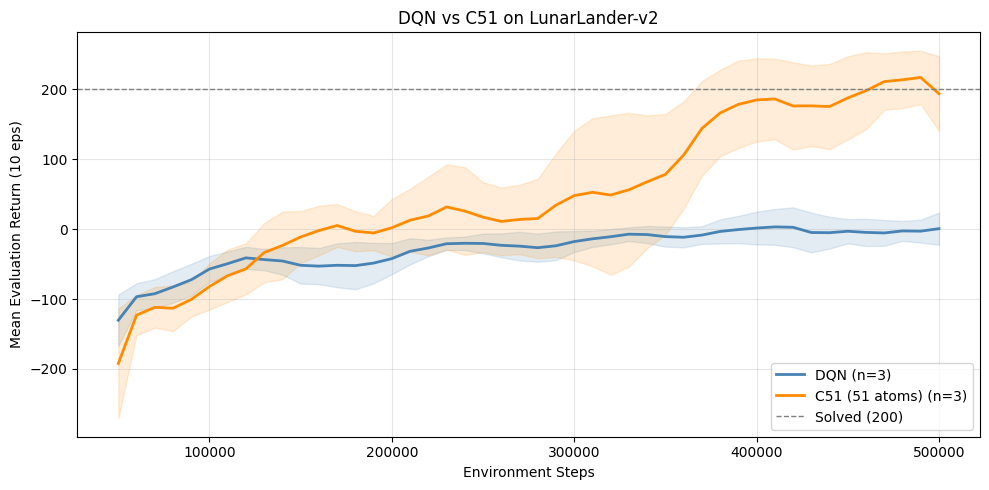

Saved -> results/dqn_vs_c51.png


In [14]:
# --- Plot 1: DQN vs C51 (51 atoms) ---
plot_comparison(
    configs=[
        ('DQN',           'steelblue',  'dqn'),
        ('C51 (51 atoms)', 'darkorange', 'c51_atoms51'),
    ],
    title='DQN vs C51 on LunarLander-v2',
    save_path=os.path.join(RESULTS_DIR, 'dqn_vs_c51.png'),
)

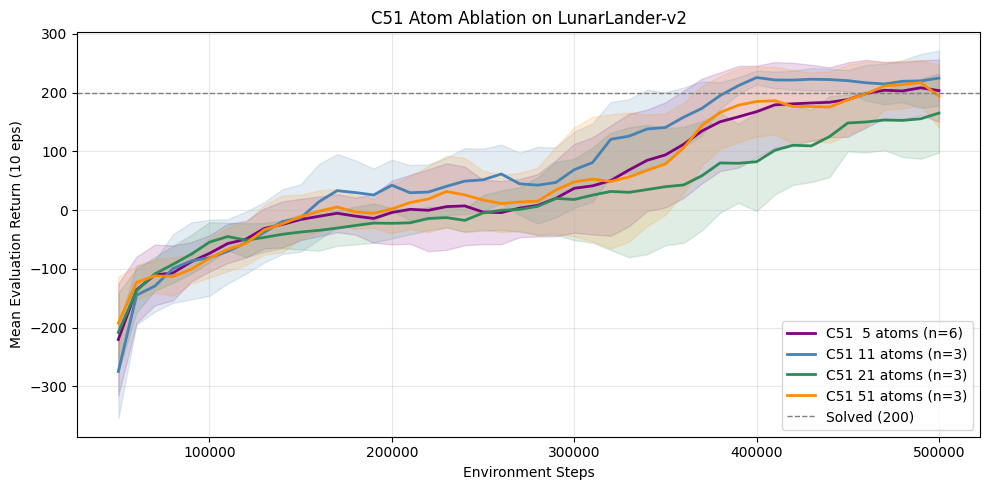

Saved -> results/atom_ablation.png


In [15]:
# --- Plot 2: C51 Atom Ablation ---
plot_comparison(
    configs=[
        ('C51  5 atoms',  'purple',      'c51_atoms5'),
        ('C51 11 atoms',  'steelblue',   'c51_atoms11'),
        ('C51 21 atoms',  'seagreen',    'c51_atoms21'),
        ('C51 51 atoms',  'darkorange',  'c51_atoms51'),
    ],
    title='C51 Atom Ablation on LunarLander-v2',
    save_path=os.path.join(RESULTS_DIR, 'atom_ablation.png'),
)

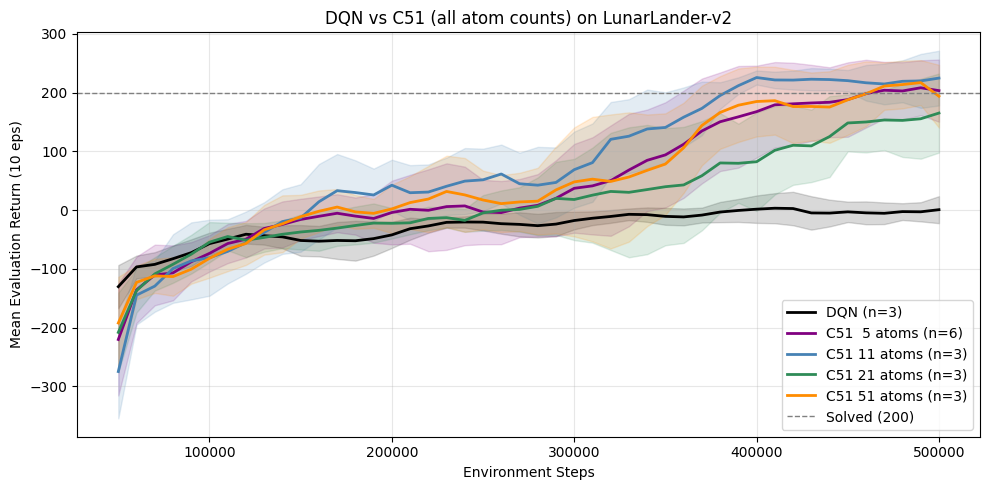

Saved -> results/all_comparison.png


In [16]:
# --- Plot 3: All configurations together ---
plot_comparison(
    configs=[
        ('DQN',           'black',       'dqn'),
        ('C51  5 atoms',  'purple',      'c51_atoms5'),
        ('C51 11 atoms',  'steelblue',   'c51_atoms11'),
        ('C51 21 atoms',  'seagreen',    'c51_atoms21'),
        ('C51 51 atoms',  'darkorange',  'c51_atoms51'),
    ],
    title='DQN vs C51 (all atom counts) on LunarLander-v2',
    save_path=os.path.join(RESULTS_DIR, 'all_comparison.png'),
)

In [17]:
# --- Summary table: final mean return per configuration ---
configs = [
    ('DQN',            'dqn'),
    ('C51  5 atoms',   'c51_atoms5'),
    ('C51 11 atoms',   'c51_atoms11'),
    ('C51 21 atoms',   'c51_atoms21'),
    ('C51 51 atoms',   'c51_atoms51'),
]

print(f'{"Config":<20}  {"Mean final return":>20}  {"Std":>8}  {"Seeds":>6}')
print('-' * 60)
for label, prefix in configs:
    steps, returns = load_runs(RESULTS_DIR, prefix)
    if steps is None:
        continue
    # Average over the last 5 evaluation points
    final = returns[:, -5:].mean(axis=1)
    print(f'{label:<20}  {final.mean():>+20.1f}  {final.std():>8.1f}  {len(final):>6}')

Config                   Mean final return       Std   Seeds
------------------------------------------------------------
DQN                                   +0.8      20.8       3
C51  5 atoms                        +203.3      39.1       6
C51 11 atoms                        +224.7      46.0       3
C51 21 atoms                        +165.2      60.7       3
C51 51 atoms                        +193.8      53.2       3
